In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Supply_chain_dataset.csv", encoding = "latin-1")
print(df.shape)
print(df.columns.tolist())

(3089, 22)
['price_per_unit', 'quality_score', 'delivery_time_days', 'on_time_delivery_rate', 'defect_rate', 'return_rate', 'delivery_mode', 'lead_time_variance', 'forecast_accuracy', 'seasonality_index', 'demand_volatility_index', 'order_frequency_monthly', 'avg_order_volume', 'payment_term_days', 'offer_validity_days', 'procurement_action_code', 'delivery_term_code', 'items_requested', 'items_offered', 'temporal_month', 'supplier_reliability_score', 'selected_supplier_flag']


In [9]:
for col in df.columns:
    print(col)
df.head()    

price_per_unit
quality_score
delivery_time_days
on_time_delivery_rate
defect_rate
return_rate
delivery_mode
lead_time_variance
forecast_accuracy
seasonality_index
demand_volatility_index
order_frequency_monthly
avg_order_volume
payment_term_days
offer_validity_days
procurement_action_code
delivery_term_code
items_requested
items_offered
temporal_month
supplier_reliability_score
selected_supplier_flag


,price_per_unit,quality_score,delivery_time_days,on_time_delivery_rate,defect_rate,return_rate,delivery_mode,lead_time_variance,forecast_accuracy,seasonality_index,...,avg_order_volume,payment_term_days,offer_validity_days,procurement_action_code,delivery_term_code,items_requested,items_offered,temporal_month,supplier_reliability_score,selected_supplier_flag
0,218.54,3.28,13,0.82,0.01,0.04,Sea,2.67,0.64,1.03,...,3677.39,30,46,3,0,885,423,9,0.60,1
1,477.82,5.05,2,0.89,0.06,0.02,Road,1.68,0.85,0.84,...,4533.31,45,19,0,2,941,608,11,0.34,0
2,379.40,9.62,2,0.71,0.07,0.04,Sea,1.66,0.70,1.03,...,2983.06,90,58,2,2,746,683,1,0.33,0
3,319.40,4.59,15,0.72,0.02,0.02,Road,4.49,0.92,1.18,...,7687.09,90,15,3,2,275,890,3,0.87,1
4,120.21,8.56,23,0.84,0.04,0.05,Road,2.26,0.76,0.94,...,4154.52,45,11,3,0,171,895,1,0.54,0


In [4]:
print(df.isnull().sum())

price_per_unit                0
quality_score                 0
delivery_time_days            0
on_time_delivery_rate         0
defect_rate                   0
return_rate                   0
delivery_mode                 0
lead_time_variance            0
forecast_accuracy             0
seasonality_index             0
demand_volatility_index       0
order_frequency_monthly       0
avg_order_volume              0
payment_term_days             0
offer_validity_days           0
procurement_action_code       0
delivery_term_code            0
items_requested               0
items_offered                 0
temporal_month                0
supplier_reliability_score    0
selected_supplier_flag        0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [11]:
print(df['on_time_delivery_rate'].describe())


count    3089.000000
mean        0.848514
std         0.085293
min         0.700000
25%         0.780000
50%         0.850000
75%         0.920000
max         1.000000
Name: on_time_delivery_rate, dtype: float64


In [ ]:
df = df.reset_index().rename(columns={"index": "offer_id"})

supplier_metrics = df[[
    "offer_id",
    "on_time_delivery_rate",
    "defect_rate",
    "return_rate",
    "price_per_unit",
    "quality_score",
    "supplier_reliability_score"
]].copy()

print(supplier_metrics.shape)
print(supplier_metrics.head())

(3089, 7)
   offer_id  on_time_delivery_rate  defect_rate  return_rate  price_per_unit  \
0         0                   0.82         0.01         0.04          218.54   
1         1                   0.89         0.06         0.02          477.82   
2         2                   0.71         0.07         0.04          379.40   
3         3                   0.72         0.02         0.02          319.40   
4         4                   0.84         0.04         0.05          120.21   

   quality_score  supplier_reliability_score  
0           3.28                        0.60  
1           5.05                        0.34  
2           9.62                        0.33  
3           4.59                        0.87  
4           8.56                        0.54  


In [14]:
# "Good" metrics — higher is better, score normally
supplier_metrics["on_time_score"] = pd.qcut(supplier_metrics["on_time_delivery_rate"], 5, labels=[1,2,3,4,5]).astype(int)
supplier_metrics["quality_score_score"] = pd.qcut(supplier_metrics["quality_score"], 5, labels=[1,2,3,4,5]).astype(int)
supplier_metrics["reliability_score_score"] = pd.qcut(supplier_metrics["supplier_reliability_score"], 5, labels=[1,2,3,4,5]).astype(int)

# "Bad" metrics — lower is better, so REVERSE the labels
supplier_metrics["defect_score"] = pd.qcut(supplier_metrics["defect_rate"], 5, labels=[5,4,3,2,1]).astype(int)
supplier_metrics["return_score"] = pd.qcut(supplier_metrics["return_rate"], 5, labels=[5,4,3,2,1]).astype(int)

print(supplier_metrics.head())

   offer_id  on_time_delivery_rate  defect_rate  return_rate  price_per_unit  \
0         0                   0.82         0.01         0.04          218.54   
1         1                   0.89         0.06         0.02          477.82   
2         2                   0.71         0.07         0.04          379.40   
3         3                   0.72         0.02         0.02          319.40   
4         4                   0.84         0.04         0.05          120.21   

   quality_score  supplier_reliability_score  on_time_score  \
0           3.28                        0.60              2   
1           5.05                        0.34              4   
2           9.62                        0.33              1   
3           4.59                        0.87              1   
4           8.56                        0.54              3   

   quality_score_score  reliability_score_score  defect_score  return_score  
0                    2                        3             5 

In [15]:
# Straight sum
supplier_metrics["performance_score"] = (
    supplier_metrics["on_time_score"]
    + supplier_metrics["quality_score_score"]
    + supplier_metrics["reliability_score_score"]
    + supplier_metrics["defect_score"]
    + supplier_metrics["return_score"]
)

print(supplier_metrics["performance_score"].describe())

count    3089.000000
mean       15.471350
std         3.069453
min         7.000000
25%        13.000000
50%        16.000000
75%        18.000000
max        25.000000
Name: performance_score, dtype: float64


In [21]:
# Data-driven thresholds using quantiles of the composite score itself
q_low = supplier_metrics["performance_score"].quantile(0.25)
q_high = supplier_metrics["performance_score"].quantile(0.75)

def segment(score):
    if score >= q_high:
        return "Preferred"
    elif score <= q_low:
        return "High Risk"
    else:
        return "Acceptable"

supplier_metrics["segment"] = supplier_metrics["performance_score"].apply(segment)

print(supplier_metrics["segment"].value_counts())

segment
Acceptable    1455
High Risk      824
Preferred      810
Name: count, dtype: int64


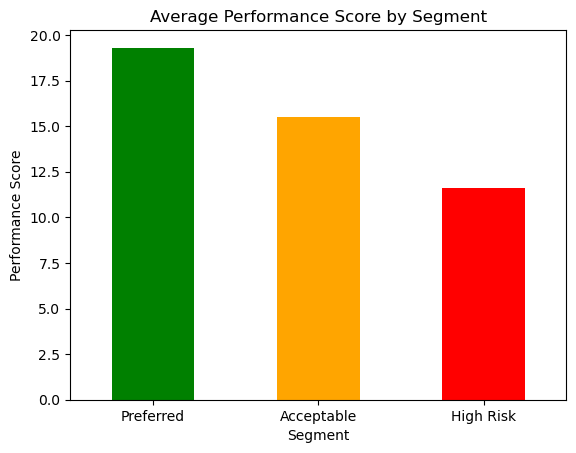

In [17]:
segment_avg = supplier_metrics.groupby("segment")["performance_score"].mean().sort_values(ascending=False)

segment_avg.plot(kind="bar", color=["green", "orange", "red"])
plt.title("Average Performance Score by Segment")
plt.ylabel("Performance Score")
plt.xlabel("Segment")
plt.xticks(rotation=0)
plt.show()

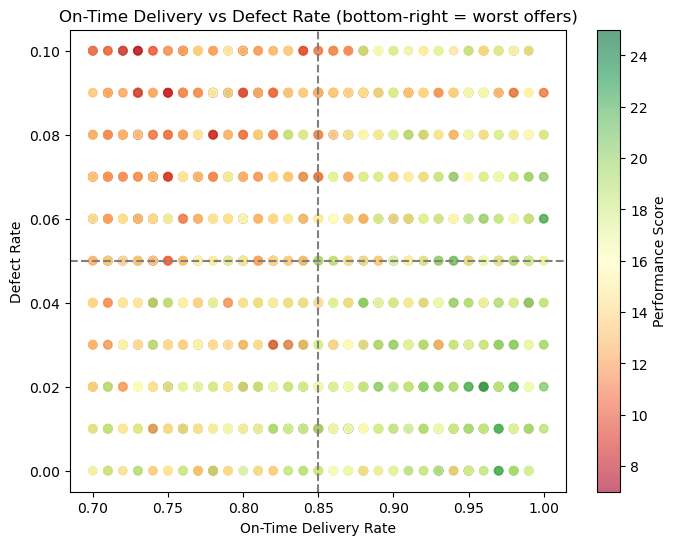

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(supplier_metrics["on_time_delivery_rate"], supplier_metrics["defect_rate"],
            c=supplier_metrics["performance_score"], cmap="RdYlGn", alpha=0.6)

median_on_time = supplier_metrics["on_time_delivery_rate"].median()
median_defect = supplier_metrics["defect_rate"].median()

plt.axvline(median_on_time, color="gray", linestyle="--")
plt.axhline(median_defect, color="gray", linestyle="--")

plt.colorbar(label="Performance Score")
plt.xlabel("On-Time Delivery Rate")
plt.ylabel("Defect Rate")
plt.title("On-Time Delivery vs Defect Rate (bottom-right = worst offers)")
plt.show()

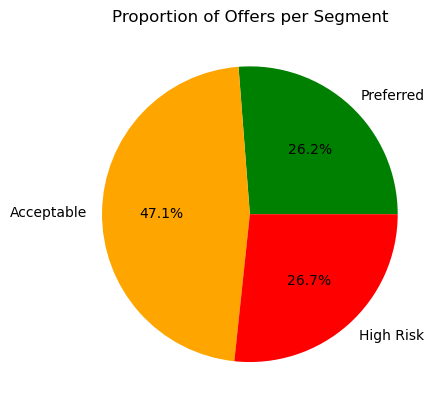

In [20]:
supplier_metrics["segment"].value_counts().reindex(["Preferred","Acceptable","High Risk"]).plot(
    kind="pie", autopct="%1.1f%%", colors=["green","orange","red"]
)
plt.title("Proportion of Offers per Segment")
plt.ylabel("")
plt.show()

In [24]:
correlation_matrix = supplier_metrics[[
    "on_time_delivery_rate", "defect_rate", "return_rate",
    "price_per_unit", "quality_score", "performance_score"
]].corr()

print(correlation_matrix)

                       on_time_delivery_rate  defect_rate  return_rate  \
on_time_delivery_rate               1.000000     0.011770     0.018797   
defect_rate                         0.011770     1.000000    -0.041748   
return_rate                         0.018797    -0.041748     1.000000   
price_per_unit                      0.004517    -0.017513     0.027552   
quality_score                      -0.012408     0.000150     0.017843   
performance_score                   0.427985    -0.437088    -0.393281   

                       price_per_unit  quality_score  performance_score  
on_time_delivery_rate        0.004517      -0.012408           0.427985  
defect_rate                 -0.017513       0.000150          -0.437088  
return_rate                  0.027552       0.017843          -0.393281  
price_per_unit               1.000000       0.014680           0.026221  
quality_score                0.014680       1.000000           0.437693  
performance_score            0.026221

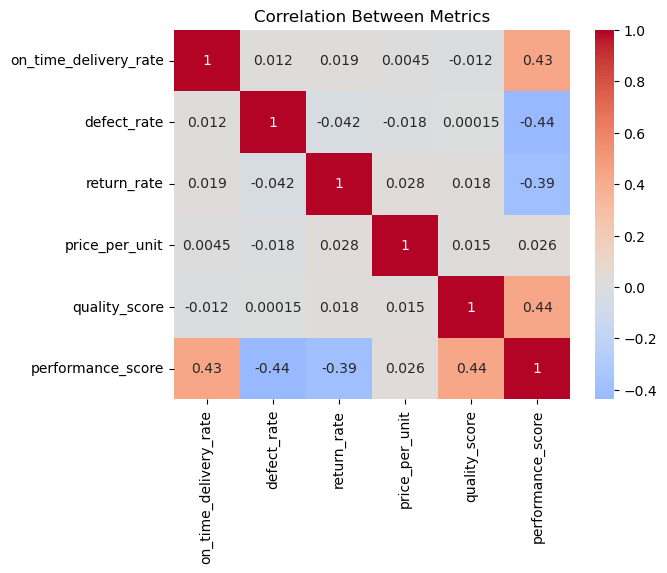

In [25]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Metrics")
plt.show()

In [26]:
df.groupby("delivery_mode")[["on_time_delivery_rate", "defect_rate", "return_rate"]].mean()

,on_time_delivery_rate,defect_rate,return_rate
delivery_mode,,,
Air,0.846429,0.050978,0.025646
Road,0.851920,0.049612,0.024947
Sea,0.847181,0.049083,0.025125


## Findings

### Overview
- Total offers analyzed: 3,089
- Segment breakdown: 26.2% Preferred, 47.1% Acceptable, 26.7% High Risk

### Correlation patterns
- Quality score and on-time delivery are the strongest positive drivers of 
  performance_score (r = 0.44 and 0.43 respectively)
- Defect rate and return rate are the strongest negative drivers (r = -0.44 and -0.39)
- Price per unit shows almost no correlation with performance_score (r = 0.03), 
  suggesting price alone is not a good predictor of offer quality

### Delivery mode pattern
- No meaningful difference in on-time delivery, defect rate, or return rate 
  across Air, Road, and Sea delivery modes — delivery mode does not appear 
  to be a significant driver of offer performance in this dataset

### Best/worst-performing offers
[fill in based on top_offers / bottom_offers table you generate]